# 📊 Marketing Analytics — E-Commerce Marketplace
**Capstone Project**

| Detail | Value |
|---|---|
| **Data Period** | Sep 2016 – Oct 2018 |
| **Total Records** | ~570,000 rows across 8 tables |
| **Objective** | Data-driven insights on revenue, customers, products, sellers, channels & satisfaction |

---
### 📋 Table of Contents
1. [Environment Setup & Data Loading](#1)
2. [Data Cleaning & Quality Check](#2)
3. [High-Level Business KPIs](#3)
4. [Customer Acquisition & Retention](#4)
5. [Revenue Trends & Seasonality](#5)
6. [Product & Category Analysis](#6)
7. [Geo-Location Analysis](#7)
8. [Customer & Seller Segmentation (RFM)](#8)
9. [Cross-Selling Analysis](#9)
10. [Payment Behaviour](#10)
11. [Customer Satisfaction (Ratings)](#11)
12. [Key Insights Summary](#12)

---
## 1. Environment Setup & Data Loading <a id='1'></a>

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from itertools import combinations
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ──Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 12,
})
PALETTE = sns.color_palette('Set2')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:


DATA_DIR = 'C:/Users/Admin/Desktop/Python class/Python Exercises/5. Python Foundation End to End Case Study_E-Commerce Analytics Project/'   # e.g. './data/'  or  'C:/Users/you/capstone/'

# ── Load all 8 tables ─────────────────────────────────────────────────────────
customers      = pd.read_csv(DATA_DIR + 'CUSTOMERS.csv')
sellers        = pd.read_csv(DATA_DIR + 'SELLERS.csv')
products       = pd.read_csv(DATA_DIR + 'PRODUCTS.csv')
orders         = pd.read_csv(DATA_DIR + 'ORDERS.csv')
order_items    = pd.read_csv(DATA_DIR + 'ORDER_ITEMS.csv')
order_payments = pd.read_csv(DATA_DIR + 'ORDER_PAYMENTS.csv')
order_reviews  = pd.read_csv(DATA_DIR + 'ORDER_REVIEW_RATINGS.csv')
geo_location   = pd.read_csv(DATA_DIR + 'GEO_LOCATION.csv')

tables = [
    ('CUSTOMERS',            customers),
    ('SELLERS',              sellers),
    ('PRODUCTS',             products),
    ('ORDERS',               orders),
    ('ORDER_ITEMS',          order_items),
    ('ORDER_PAYMENTS',       order_payments),
    ('ORDER_REVIEW_RATINGS', order_reviews),
    ('GEO_LOCATION',         geo_location),
]

print(f'  {"Table":<25} {"Rows":>8}  {"Cols":>5}')
print('  ' + '-'*42)
for name, df in tables:
    print(f'  {name:<25} {df.shape[0]:>8,}  {df.shape[1]:>5}')
print(f'\n  Total rows: {sum(df.shape[0] for _,df in tables):,}')

  Table                         Rows   Cols
  ------------------------------------------
  CUSTOMERS                   99,441      5
  SELLERS                      3,095      4
  PRODUCTS                    32,951      9
  ORDERS                      99,441      8
  ORDER_ITEMS                112,650      7
  ORDER_PAYMENTS             103,886      5
  ORDER_REVIEW_RATINGS       100,000      5
  GEO_LOCATION                19,015      5

  Total rows: 570,479


---
## 2. Data Cleaning & Quality Check <a id='2'></a>

In [3]:
def quality_report(df, name):
    """Shows missing values, %, and duplicate count for a DataFrame."""
    print(f'\n{"-"*52}')
    print(f'  TABLE: {name}  ({df.shape[0]:,} rows x {df.shape[1]} cols)')
    print(f'{"-"*52}')
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    report  = pd.DataFrame({'missing_count': missing, 'missing_%': pct, 'dtype': df.dtypes})
    has_missing = report[report['missing_count'] > 0]
    if len(has_missing):
        print(has_missing.to_string())
    else:
        print('  ✅ No missing values')
    dups = df.duplicated().sum()
    print(f'  Duplicate rows: {dups}')

for name, df in tables[:-1]:   # skip geo (expected duplicates by design)
    quality_report(df, name)


----------------------------------------------------
  TABLE: CUSTOMERS  (99,441 rows x 5 cols)
----------------------------------------------------
  ✅ No missing values
  Duplicate rows: 0

----------------------------------------------------
  TABLE: SELLERS  (3,095 rows x 4 cols)
----------------------------------------------------
              missing_count  missing_%   dtype
seller_city              57       1.84  object
seller_state             57       1.84  object
  Duplicate rows: 0

----------------------------------------------------
  TABLE: PRODUCTS  (32,951 rows x 9 cols)
----------------------------------------------------
                            missing_count  missing_%    dtype
product_category_name                 623       1.89   object
product_name_lenght                   610       1.85  float64
product_description_lenght            610       1.85  float64
product_photos_qty                    610       1.85  float64
product_weight_g                        2

In [4]:
# ── Fix: product_category_name has 623 nulls → fill with 'Unknown' ────────────
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

# ── Parse all datetime columns ────────────────────────────────────────────────
DATE_COLS = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in DATE_COLS:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], dayfirst=False, errors='coerce')

# ── Derived time features ─────────────────────────────────────────────────────
ts = orders['order_purchase_timestamp']
orders['order_year']   = ts.dt.year
orders['year_month']   = ts.dt.strftime('%Y-%m')
orders['order_month']  = ts.dt.to_period('M')
orders['order_week']   = ts.dt.isocalendar().week.astype('Int64')
orders['order_dow']    = ts.dt.day_name()
orders['order_hour']   = ts.dt.hour

# ── Delivery time (days) ──────────────────────────────────────────────────────
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# ── Filter valid orders for revenue analysis ──────────────────────────────────
VALID_STATUS  = ['delivered', 'shipped', 'invoiced']
orders_valid  = orders[orders['order_status'].isin(VALID_STATUS)].copy()

print(f'Total orders          : {len(orders):,}')
print(f'Valid (revenue) orders: {len(orders_valid):,}  ({len(orders_valid)/len(orders)*100:.1f}%)')
print(f'\nOrder status breakdown:')
print(orders['order_status'].value_counts().to_string())

Total orders          : 99,441
Valid (revenue) orders: 97,899  (98.4%)

Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


In [5]:
# ── Build Master Fact Table ───────────────────────────────────────────────────
# Deduplicate payments per order (sum payment_value, keep first payment_type)
payments_agg = (
    order_payments
    .groupby('order_id')
    .agg(
        payment_value   = ('payment_value',    'sum'),
        payment_type    = ('payment_type',     'first'),
        payment_installments = ('payment_installments', 'max'),
    )
    .reset_index()
)

master = (
    orders_valid
    .merge(order_items,                                           on='order_id',    how='left')
    .merge(payments_agg,                                          on='order_id',    how='left')
    .merge(customers,                                             on='customer_id', how='left')
    .merge(products[['product_id','product_category_name']],      on='product_id',  how='left')
    .merge(sellers[['seller_id','seller_city','seller_state']],   on='seller_id',   how='left')
)
master['product_category_name'] = master['product_category_name'].fillna('Unknown')

print(f'Master table shape : {master.shape}')
print(f'Columns            : {list(master.columns)}')

Master table shape : (111744, 31)
Columns            : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_year', 'year_month', 'order_month', 'order_week', 'order_dow', 'order_hour', 'delivery_days', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_value', 'payment_type', 'payment_installments', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'seller_city', 'seller_state']


---
## 3. High-Level Business KPIs <a id='3'></a>

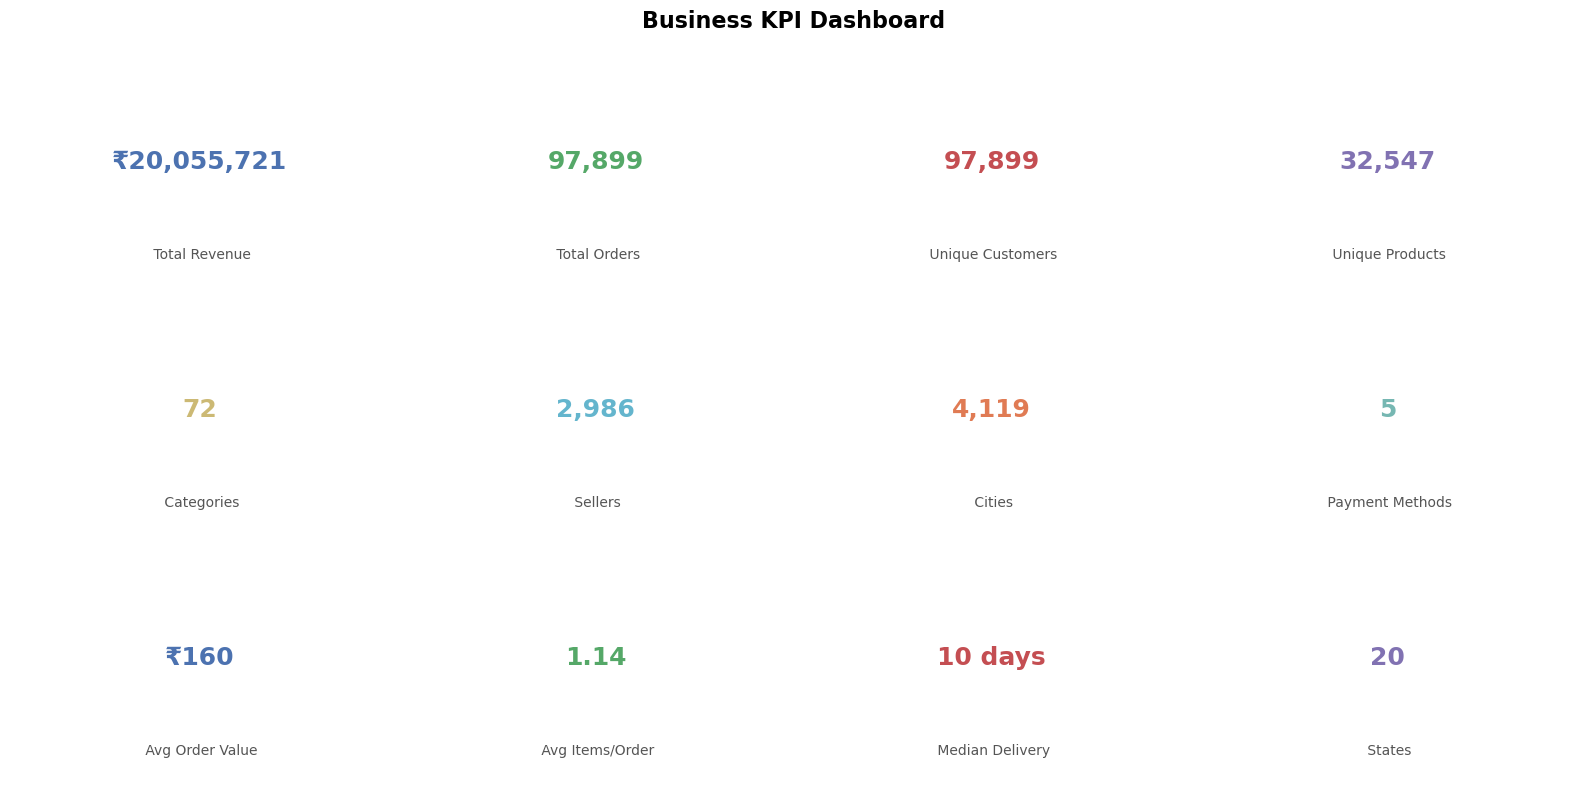

In [6]:
# ── Compute KPIs ──────────────────────────────────────────────────────────────
total_revenue   = master['payment_value'].sum()
total_orders    = master['order_id'].nunique()
total_customers = master['customer_id'].nunique()
total_products  = master['product_id'].nunique()
total_categories= master['product_category_name'].nunique()
total_sellers   = master['seller_id'].nunique()
total_cities    = customers['customer_city'].nunique()
total_states    = customers['customer_state'].nunique()
total_pay_types = order_payments['payment_type'].nunique()
avg_order_value = master.groupby('order_id')['payment_value'].first().mean()
avg_items_order = master.groupby('order_id')['order_item_id'].count().mean()
avg_delivery    = orders_valid['delivery_days'].median()

kpi_display = [
    (' Total Revenue',      f'₹{total_revenue:,.0f}',    '#4C72B0'),
    (' Total Orders',       f'{total_orders:,}',          '#55A868'),
    (' Unique Customers',   f'{total_customers:,}',       '#C44E52'),
    (' Unique Products',    f'{total_products:,}',        '#8172B2'),
    (' Categories',        f'{total_categories}',        '#CCB974'),
    (' Sellers',            f'{total_sellers:,}',         '#64B5CD'),
    (' Cities',             f'{total_cities:,}',          '#E07B54'),
    (' Payment Methods',    f'{total_pay_types}',         '#76B7B2'),
    (' Avg Order Value',    f'₹{avg_order_value:,.0f}',   '#4C72B0'),
    (' Avg Items/Order',    f'{avg_items_order:.2f}',     '#55A868'),
    (' Median Delivery',    f'{avg_delivery:.0f} days',   '#C44E52'),
    (' States',             f'{total_states}',           '#8172B2'),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
fig.suptitle('Business KPI Dashboard', fontsize=16, fontweight='bold', y=1.01)

for ax, (label, value, color) in zip(axes.flat, kpi_display):
    ax.set_facecolor(color + '18')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.text(0.5, 0.62, value,  ha='center', va='center',
            fontsize=18, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label,  ha='center', va='center',
            fontsize=10, color='#555', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.savefig('01_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Customer Acquisition & Retention <a id='4'></a>

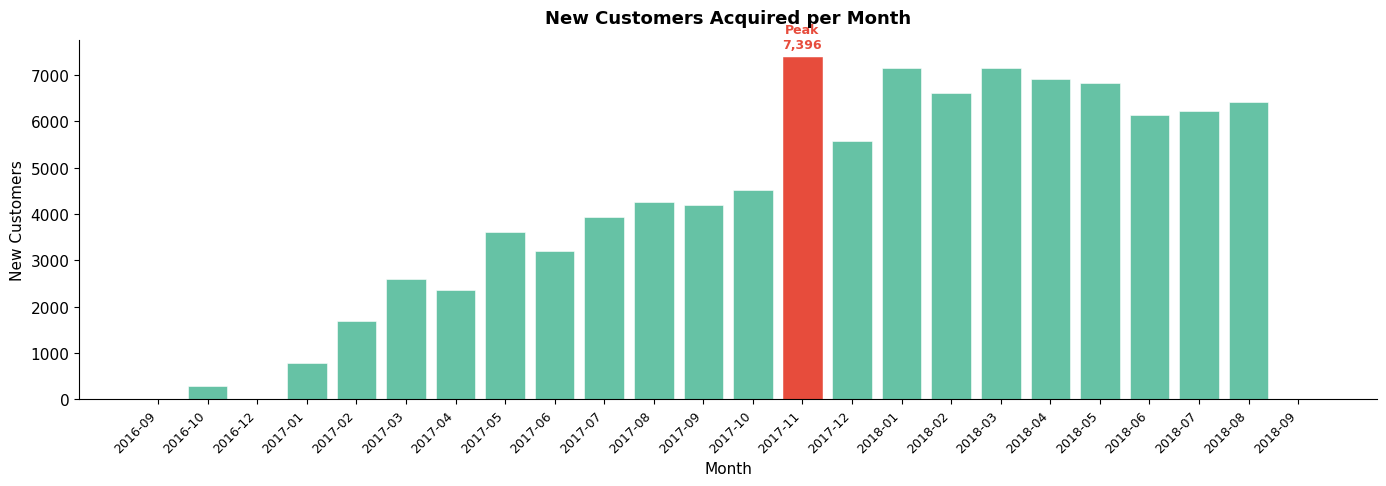


💡 Peak acquisition month : 2017-11  (7,396 new customers)
   Total unique customers  : 97,899


In [14]:
# ── New customers acquired each month ─────────────────────────────────────────
first_order = (
    orders_valid
    .sort_values('order_purchase_timestamp')
    .groupby('customer_id')['order_purchase_timestamp']
    .min()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'first_order_date'})
)
first_order['acq_month']  = first_order['first_order_date'].dt.to_period('M')
first_order['acq_ym']     = first_order['first_order_date'].dt.strftime('%Y-%m')

new_cust_monthly = (
    first_order
    .groupby('acq_ym')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'new_customers'})
)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    new_cust_monthly['acq_ym'],
    new_cust_monthly['new_customers'],
    color=PALETTE[0], edgecolor='white', linewidth=0.4
)

# Annotate peak bar
peak_idx = new_cust_monthly['new_customers'].idxmax()
bars[peak_idx].set_color('#e74c3c')
ax.annotate(
    f"Peak\n{new_cust_monthly.loc[peak_idx,'new_customers']:,}",
    xy=(peak_idx, new_cust_monthly.loc[peak_idx,'new_customers']),
    xytext=(peak_idx, new_cust_monthly.loc[peak_idx,'new_customers'] + 200),
    ha='center', fontsize=9, color='#e74c3c', fontweight='bold'
)

ax.set_title('New Customers Acquired per Month')
ax.set_xlabel('Month')
ax.set_ylabel('New Customers')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('02_new_customers_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

peak = new_cust_monthly.loc[peak_idx]
print(f'\n Peak acquisition month : {peak["acq_ym"]}  ({peak["new_customers"]:,} new customers)')
print(f'   Total unique customers  : {first_order["customer_id"].nunique():,}')

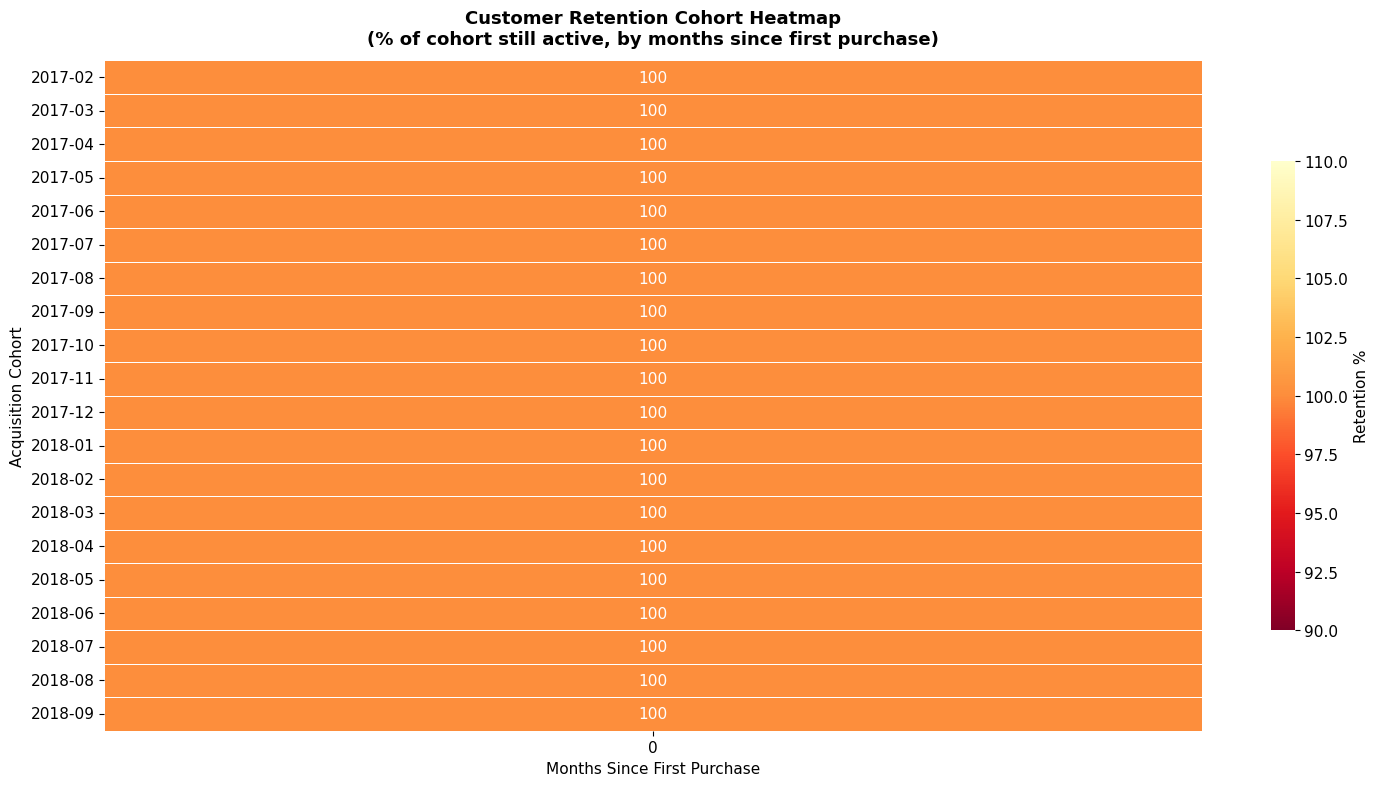

In [16]:
# ── Monthly Retention Cohort Heatmap ──────────────────────────────────────────
orders_cohort = (
    orders_valid
    .merge(first_order[['customer_id','acq_month']], on='customer_id'))

orders_cohort['order_month']   = orders_cohort['order_purchase_timestamp'].dt.to_period('M')
orders_cohort['period_number'] = (
    (orders_cohort['order_month'] - orders_cohort['acq_month'])
    .apply(lambda x: x.n))

cohort_counts = (
    orders_cohort
    .groupby(['acq_month','period_number'])['customer_id']
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_counts.pivot_table(
    index='acq_month', columns='period_number', values='customer_id'
)
cohort_size   = cohort_pivot[0]
retention_pct = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)

# Show last 20 cohorts, first 12 periods
display_cols = [c for c in retention_pct.columns if 0 <= c <= 12]
hm_data      = retention_pct[display_cols].tail(20)
hm_data.index = hm_data.index.astype(str)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    hm_data, annot=True, fmt='.0f', cmap='YlOrRd_r',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Retention %', 'shrink': 0.7},
    mask=hm_data.isnull()
)
ax.set_title('Customer Retention Cohort Heatmap\n(% of cohort still active, by months since first purchase)')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort')
plt.tight_layout()
plt.savefig('03_retention_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

if 1 in retention_pct.columns:
    avg_m1 = retention_pct[1].dropna().mean()
    print(f'\n Average Month-1 retention rate: {avg_m1:.1f}%')
    print(   '   (Low retention is typical for e-commerce marketplaces)')

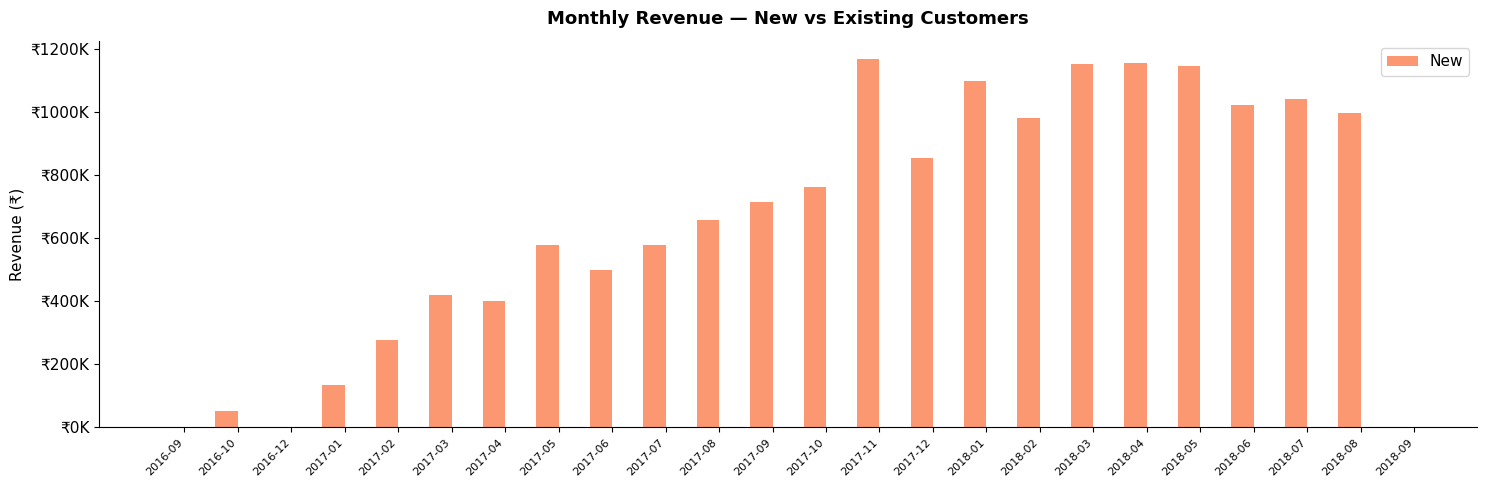

In [12]:
# ── Revenue: New vs Existing Customers MoM ────────────────────────────────────
orders_tagged = (
    orders_valid
    .merge(first_order[['customer_id','acq_month']], on='customer_id')
    .merge(payments_agg[['order_id','payment_value']], on='order_id', how='left')
)
orders_tagged['order_month'] = orders_tagged['order_purchase_timestamp'].dt.to_period('M')
orders_tagged['customer_type'] = np.where(
    orders_tagged['order_month'] == orders_tagged['acq_month'], 'New', 'Existing'
)

rev_by_type = (
    orders_tagged
    .groupby(['year_month','customer_type'])['payment_value']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

x     = np.arange(len(rev_by_type))
width = 0.42

fig, ax = plt.subplots(figsize=(15, 5))
if 'New' in rev_by_type.columns:
    ax.bar(x - width/2, rev_by_type['New'],      width, label='New',      color=PALETTE[1], alpha=0.9)
if 'Existing' in rev_by_type.columns:
    ax.bar(x + width/2, rev_by_type['Existing'], width, label='Existing', color=PALETTE[0], alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(rev_by_type['year_month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Revenue — New vs Existing Customers')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('04_revenue_new_vs_existing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Revenue Trends & Seasonality <a id='5'></a>

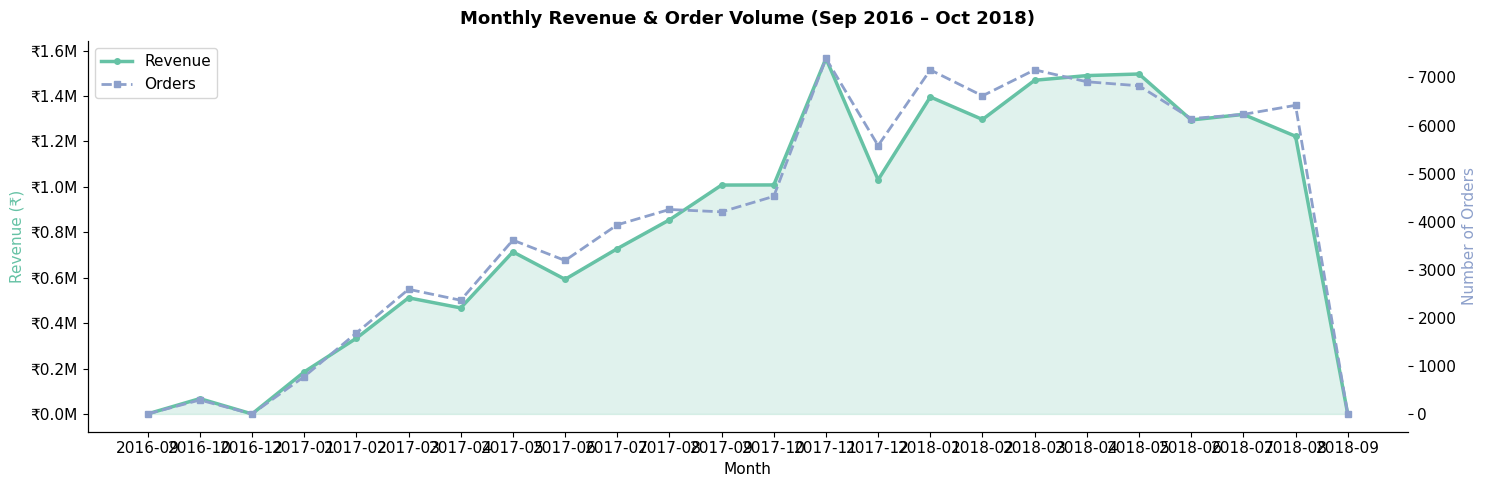


💡 Peak revenue month : 2017-11
   Peak order month   : 2017-11


In [13]:
# ── Monthly Revenue + Order Volume ────────────────────────────────────────────
monthly = (
    master
    .groupby('year_month')
    .agg(
        revenue  = ('payment_value', 'sum'),
        orders   = ('order_id',      'nunique'),
        avg_ov   = ('payment_value', 'mean'),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(15, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['year_month'], monthly['revenue'], alpha=0.2, color=PALETTE[0])
ax1.plot(monthly['year_month'], monthly['revenue'],
         color=PALETTE[0], lw=2.5, marker='o', ms=4, label='Revenue')
ax2.plot(monthly['year_month'], monthly['orders'],
         color=PALETTE[2], lw=2, ls='--', marker='s', ms=4, label='Orders')

ax1.set_title('Monthly Revenue & Order Volume (Sep 2016 – Oct 2018)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (₹)', color=PALETTE[0])
ax2.set_ylabel('Number of Orders', color=PALETTE[2])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right', fontsize=8)

lines  = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.tight_layout()
plt.savefig('05_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Peak revenue month : {monthly.loc[monthly["revenue"].idxmax(), "year_month"]}')
print(f'   Peak order month   : {monthly.loc[monthly["orders"].idxmax(), "year_month"]}')

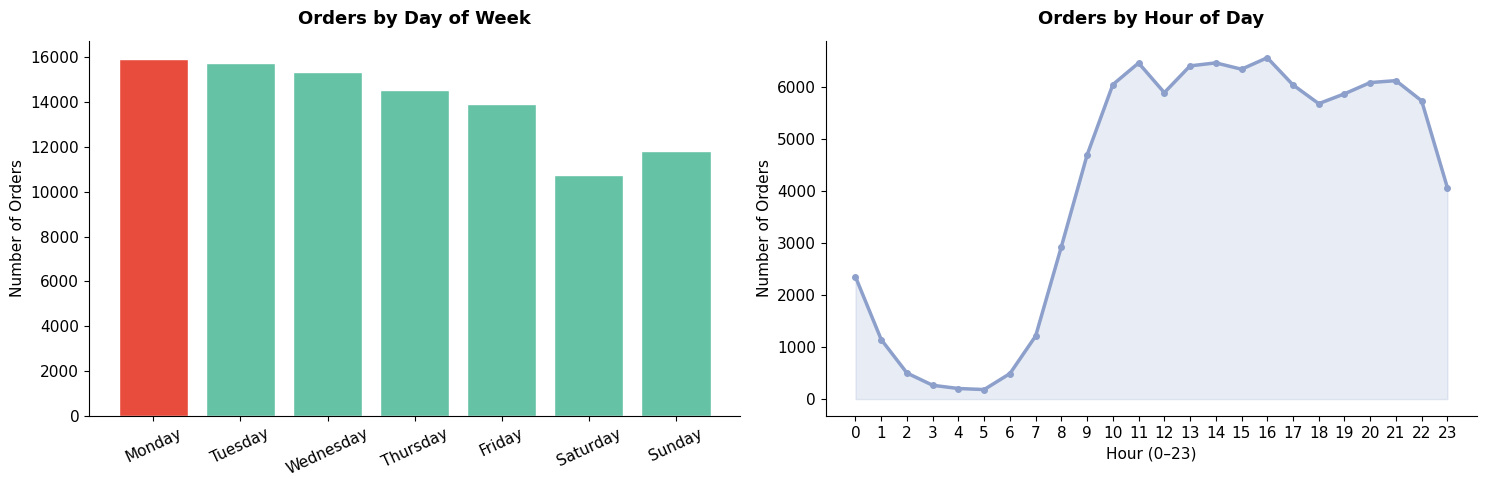

💡 Busiest day  : Monday
💡 Busiest hour : 16:00 – 17:00


In [14]:
# ── Seasonality: Day of Week + Hour of Day ────────────────────────────────────
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_data = (
    master.groupby('order_dow')['order_id']
    .nunique()
    .reindex(DOW_ORDER)
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)
hour_data = (
    master.groupby('order_hour')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_dow = ['#e74c3c' if d == dow_data.loc[dow_data['orders'].idxmax(),'order_dow']
              else PALETTE[0] for d in dow_data['order_dow']]
axes[0].bar(dow_data['order_dow'], dow_data['orders'], color=colors_dow, edgecolor='white')
axes[0].set_title('Orders by Day of Week')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=25)

axes[1].plot(hour_data['order_hour'], hour_data['orders'],
             color=PALETTE[2], lw=2.5, marker='o', ms=4)
axes[1].fill_between(hour_data['order_hour'], hour_data['orders'], alpha=0.2, color=PALETTE[2])
axes[1].set_title('Orders by Hour of Day')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('06_seasonality_dow_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_dow  = dow_data.loc[dow_data['orders'].idxmax(), 'order_dow']
peak_hour = hour_data.loc[hour_data['orders'].idxmax(), 'order_hour']
print(f'💡 Busiest day  : {peak_dow}')
print(f'💡 Busiest hour : {peak_hour}:00 – {peak_hour+1}:00')

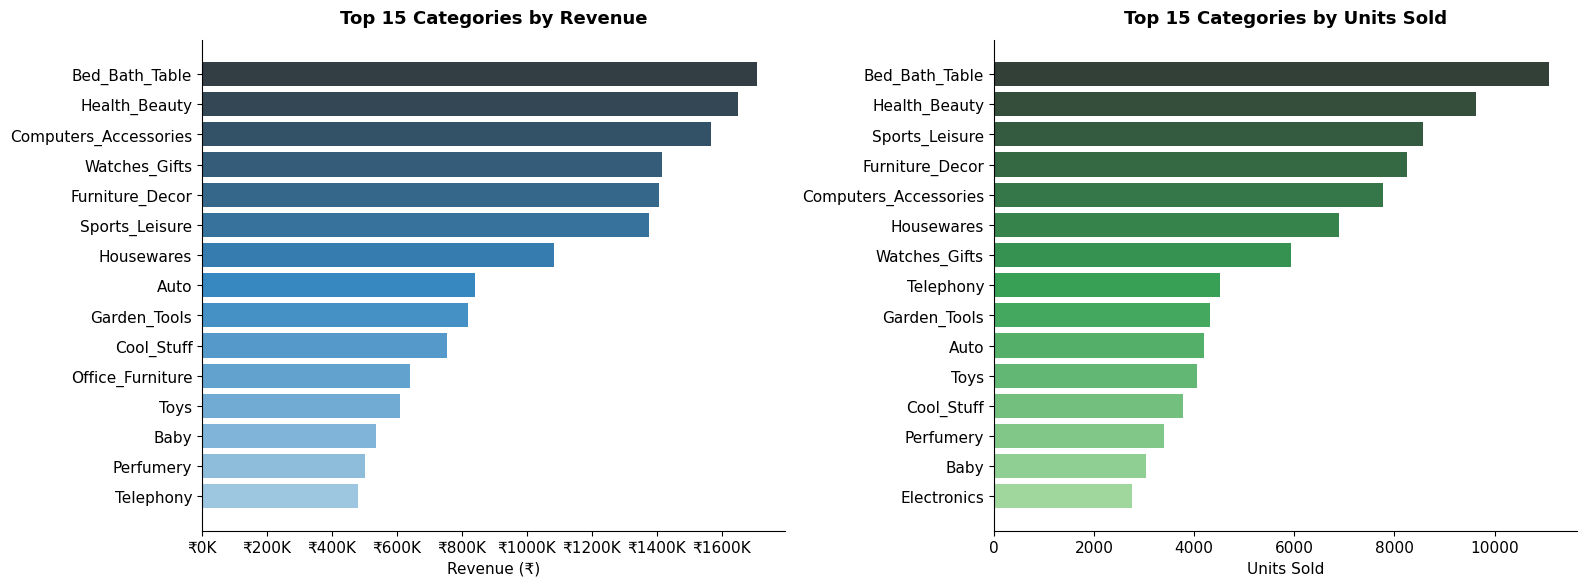

In [15]:
# ── Revenue by Category ───────────────────────────────────────────────────────
cat_rev = (
    master.groupby('product_category_name')
    .agg(
        revenue  = ('payment_value',  'sum'),
        orders   = ('order_id',       'nunique'),
        qty      = ('order_item_id',  'count'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_rev = cat_rev.head(15)
axes[0].barh(
    top15_rev['product_category_name'][::-1],
    top15_rev['revenue'][::-1],
    color=sns.color_palette('Blues_d', 15)
)
axes[0].set_title('Top 15 Categories by Revenue')
axes[0].set_xlabel('Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e3:.0f}K'))

top15_qty = cat_rev.sort_values('qty', ascending=False).head(15)
axes[1].barh(
    top15_qty['product_category_name'][::-1],
    top15_qty['qty'][::-1],
    color=sns.color_palette('Greens_d', 15)
)
axes[1].set_title('Top 15 Categories by Units Sold')
axes[1].set_xlabel('Units Sold')

plt.tight_layout()
plt.savefig('07_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

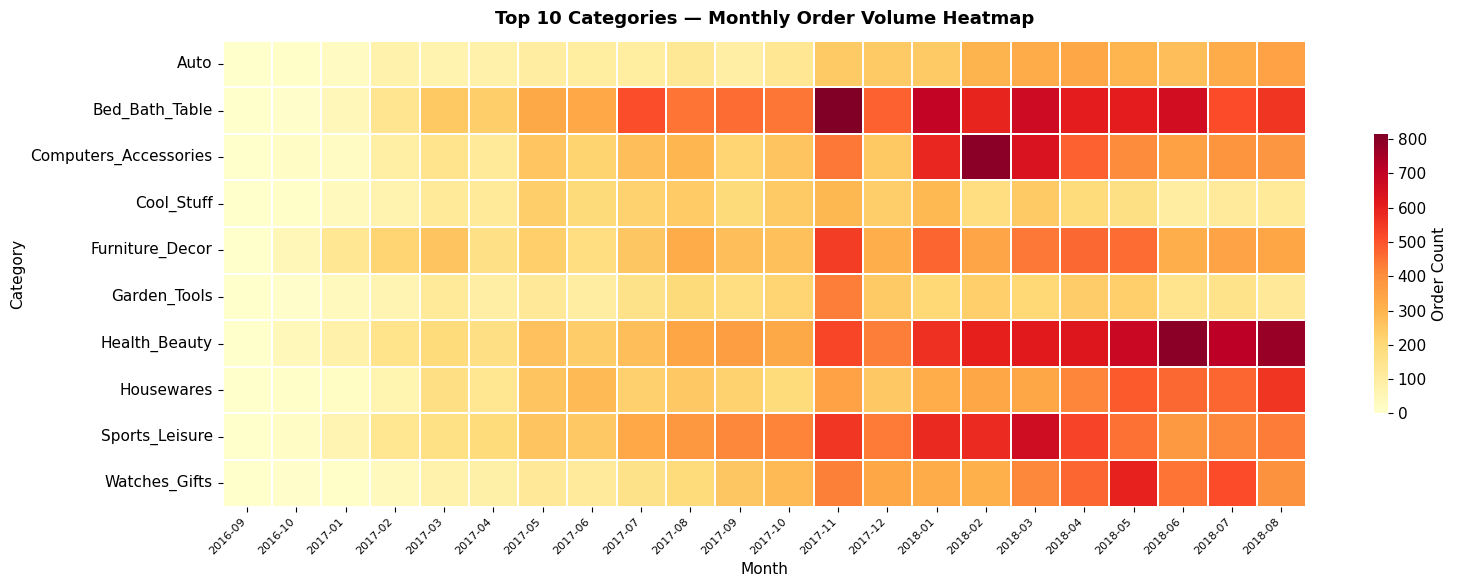

In [16]:
# ── Category × Month Heatmap ──────────────────────────────────────────────────
top10_cats = cat_rev.head(10)['product_category_name'].tolist()

cat_month = (
    master[master['product_category_name'].isin(top10_cats)]
    .groupby(['year_month','product_category_name'])['order_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    cat_month.T, cmap='YlOrRd', linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Order Count', 'shrink': 0.6}, ax=ax
)
ax.set_title('Top 10 Categories — Monthly Order Volume Heatmap')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('08_category_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Product Analysis <a id='6'></a>

In [17]:
# ── Top 10 Most Expensive Products ───────────────────────────────────────────
top_expensive = (
    order_items
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .groupby(['product_id','product_category_name'])['price']
    .max()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'price': 'max_price_inr'})
)
print('🏷️  Top 10 Most Expensive Products (by max listed price)')
print(top_expensive.to_string(index=False))

🏷️  Top 10 Most Expensive Products (by max listed price)
                      product_id product_category_name  max_price_inr
489ae2aa008f021502940f251d4cce7f            Housewares       6,735.00
69c590f7ffc7bf8db97190b6cb6ed62e             Computers       6,729.00
1bdf5e6731585cf01aa8169c7028d6ad                   Art       6,499.00
a6492cc69376c469ab6f61d8f44de961      Small_Appliances       4,799.00
c3ed642d592594bb648ff4a04cee2747      Small_Appliances       4,690.00
259037a6a41845e455183f89c5035f18             Computers       4,590.00
a1beef8f3992dbd4cd8726796aa69c53   Musical_Instruments       4,399.87
6cdf8fc1d741c76586d8b6b15e9eef30        Consoles_Games       4,099.99
dd113cb02b2af9c8e5787e8f1f0722f6        Sports_Leisure       4,059.00
6902c1962dd19d540807d0ab8fade5c6         Watches_Gifts       3,999.90


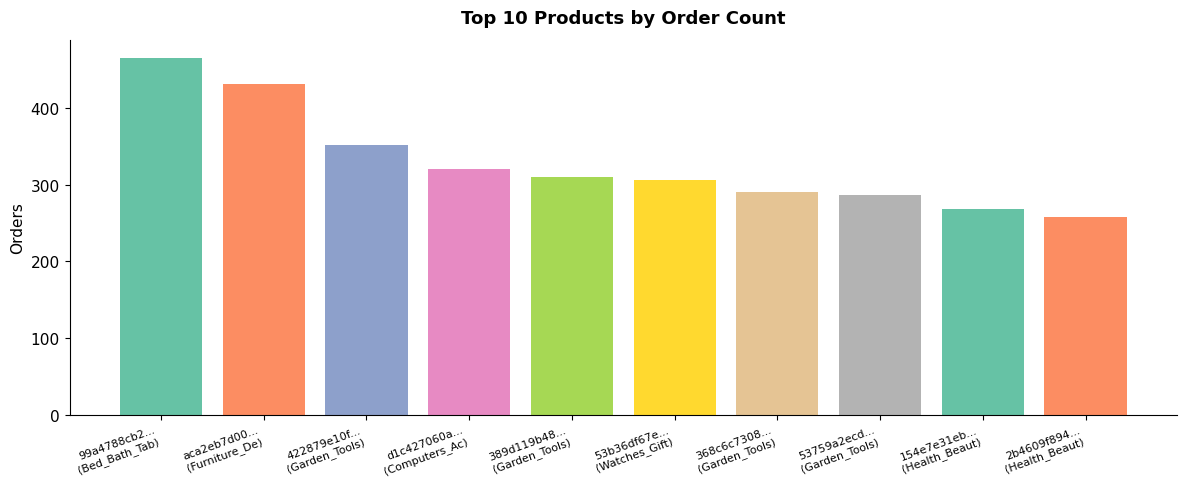

                      product_id product_category_name  order_count  total_revenue  avg_price
99a4788cb24856965c36a24e339b6058        Bed_Bath_Table          466      63,053.40      88.17
aca2eb7d00ea1a7b8ebd4e68314663af       Furniture_Decor          431      63,788.12      71.36
422879e10f46682990de24d770e7f83d          Garden_Tools          352      79,512.22      54.91
d1c427060a0f73f6b889a5c7c61f2ac4 Computers_Accessories          321      70,179.16     137.59
389d119b48cf3043d311335e499d9c6b          Garden_Tools          310      48,548.94      54.71
53b36df67ebb7c41585e8d54d6772e08         Watches_Gifts          306      48,994.30     116.67
368c6c730842d78016ad823897a372db          Garden_Tools          291      52,508.63      54.27
53759a2ecddad2bb87a079a1f1519f73          Garden_Tools          287      53,445.35      54.66
154e7e31ebfa092203795c972e5804a6         Health_Beauty          269      11,826.06      22.51
2b4609f8948be18874494203496bc318         Health_Beauty      

In [18]:
# ── Popular Products by Order Count ──────────────────────────────────────────
pop_products = (
    master
    .groupby(['product_id','product_category_name'])
    .agg(
        order_count   = ('order_id',       'nunique'),
        total_revenue = ('payment_value',  'sum'),
        avg_price     = ('price',          'mean'),
    )
    .sort_values('order_count', ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    range(len(pop_products)),
    pop_products['order_count'],
    color=PALETTE[:len(pop_products)]
)
ax.set_xticks(range(len(pop_products)))
ax.set_xticklabels(
    [f"{row['product_id'][:10]}...\n({row['product_category_name'][:12]})"
     for _, row in pop_products.iterrows()],
    rotation=20, ha='right', fontsize=8
)
ax.set_title('Top 10 Products by Order Count')
ax.set_ylabel('Orders')
plt.tight_layout()
plt.savefig('09_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print(pop_products[['product_id','product_category_name','order_count','total_revenue','avg_price']].to_string(index=False))

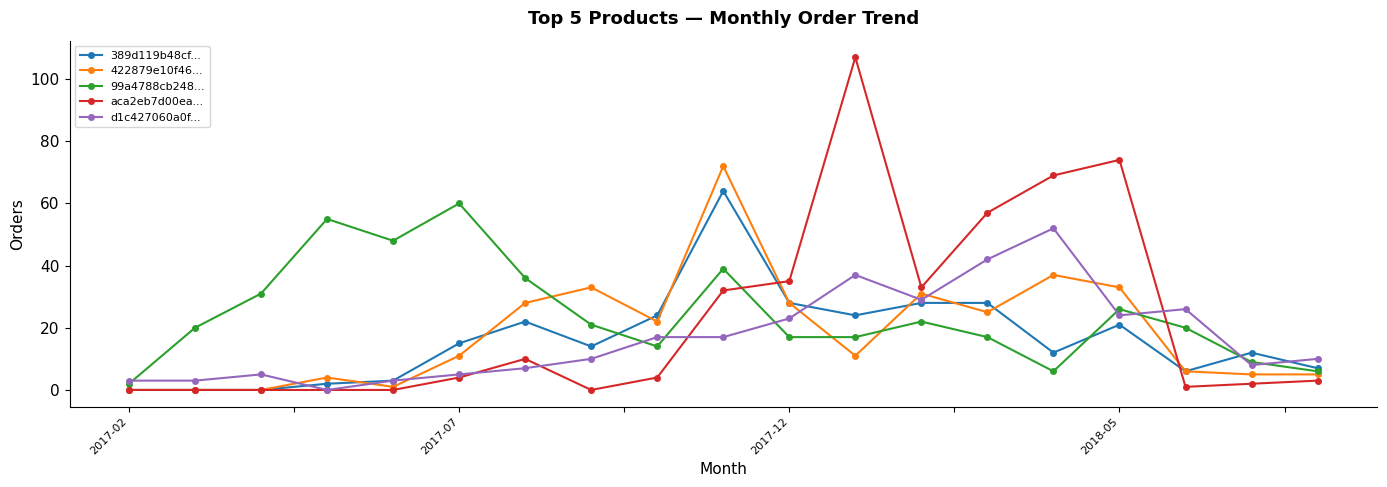

In [19]:
# ── Popular Products by Month (top 5 products × monthly orders) ───────────────
top5_products = pop_products['product_id'].head(5).tolist()

prod_month = (
    master[master['product_id'].isin(top5_products)]
    .groupby(['year_month','product_id'])['order_id']
    .nunique()
    .unstack(fill_value=0)
)
prod_month.columns = [c[:12]+'...' for c in prod_month.columns]

prod_month.plot(kind='line', figsize=(14, 5), marker='o', markersize=4)
plt.title('Top 5 Products — Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('10_top_products_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Geo-Location Analysis <a id='7'></a>

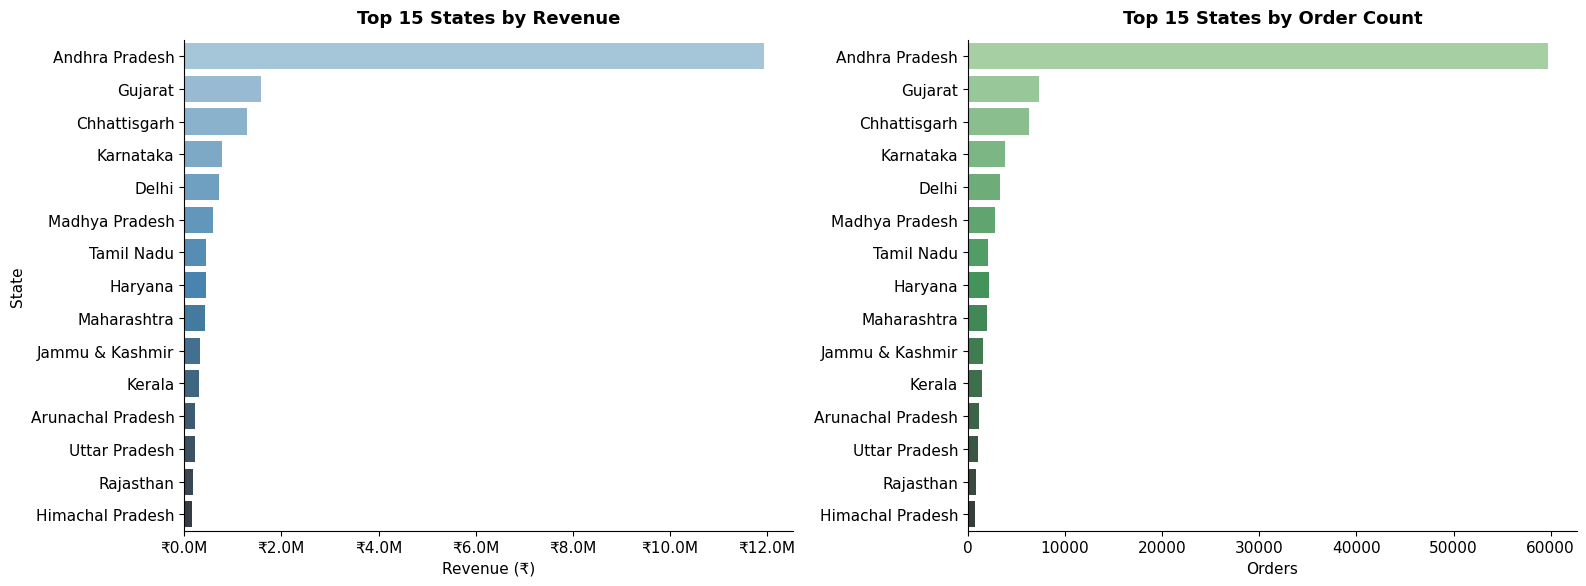


📍 Top 10 States Summary:
 customer_state       revenue  orders  customers
 Andhra Pradesh 11,939,155.87   59720      59720
        Gujarat  1,591,055.68    7355       7355
   Chhattisgarh  1,295,007.80    6254       6254
      Karnataka    783,371.92    3795       3795
          Delhi    725,381.08    3286       3286
 Madhya Pradesh    596,885.18    2806       2806
     Tamil Nadu    459,913.03    2097       2097
        Haryana    453,805.50    2163       2163
    Maharashtra    423,148.64    1977       1977
Jammu & Kashmir    332,966.76    1521       1521


In [20]:
# ── Revenue & Orders by State ─────────────────────────────────────────────────
state_agg = (
    master
    .groupby('customer_state')
    .agg(
        revenue  = ('payment_value', 'sum'),
        orders   = ('order_id',      'nunique'),
        customers= ('customer_id',   'nunique'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top15_state = state_agg.head(15)
sns.barplot(data=top15_state, y='customer_state', x='revenue',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Top 15 States by Revenue')
axes[0].set_xlabel('Revenue (₹)')
axes[0].set_ylabel('State')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e6:.1f}M'))

sns.barplot(data=top15_state, y='customer_state', x='orders',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 15 States by Order Count')
axes[1].set_xlabel('Orders')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('11_geo_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📍 Top 10 States Summary:')
print(state_agg.head(10)[['customer_state','revenue','orders','customers']].to_string(index=False))

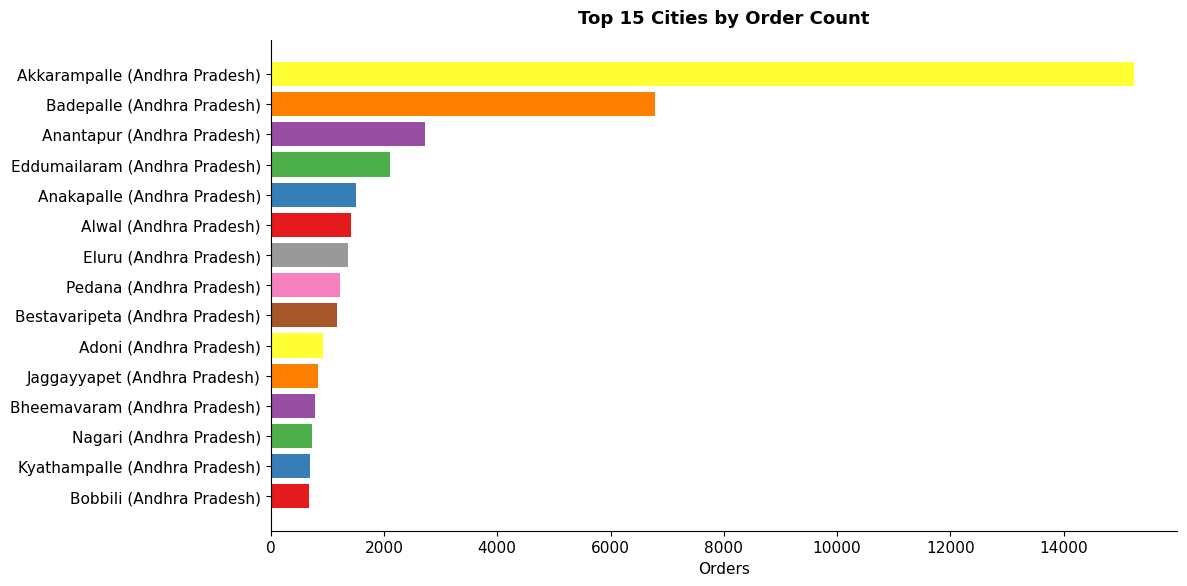

In [21]:
# ── Top 15 Cities by Orders ───────────────────────────────────────────────────
city_agg = (
    master
    .groupby(['customer_city','customer_state'])
    .agg(
        orders   = ('order_id',      'nunique'),
        revenue  = ('payment_value', 'sum'),
    )
    .sort_values('orders', ascending=False)
    .head(15)
    .reset_index()
)
city_agg['city_label'] = city_agg['customer_city'] + ' (' + city_agg['customer_state'] + ')'

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(
    city_agg['city_label'][::-1],
    city_agg['orders'][::-1],
    color=sns.color_palette('Set1', 15)
)
ax.set_title('Top 15 Cities by Order Count')
ax.set_xlabel('Orders')
plt.tight_layout()
plt.savefig('12_geo_city_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

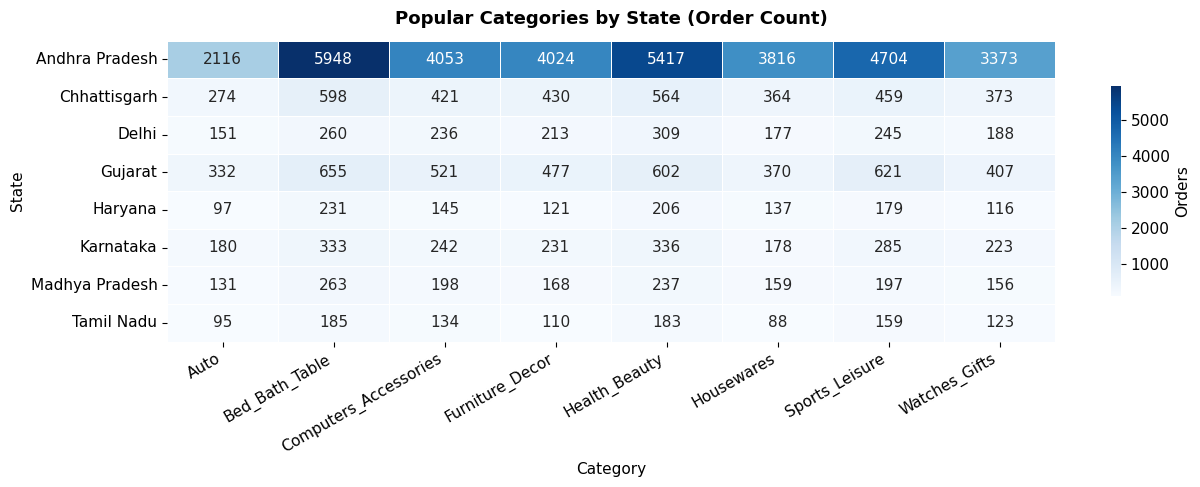

In [22]:
# ── Popular Categories by State (top 8 states × top 8 categories) ─────────────
top8_states = state_agg.head(8)['customer_state'].tolist()
top8_cats   = cat_rev.head(8)['product_category_name'].tolist()

state_cat = (
    master[
        master['customer_state'].isin(top8_states) &
        master['product_category_name'].isin(top8_cats)
    ]
    .groupby(['customer_state','product_category_name'])['order_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    state_cat, annot=True, fmt='d', cmap='Blues',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Orders', 'shrink': 0.7}
)
ax.set_title('Popular Categories by State (Order Count)')
ax.set_xlabel('Category')
ax.set_ylabel('State')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('13_category_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Customer & Seller Segmentation (RFM) <a id='8'></a>

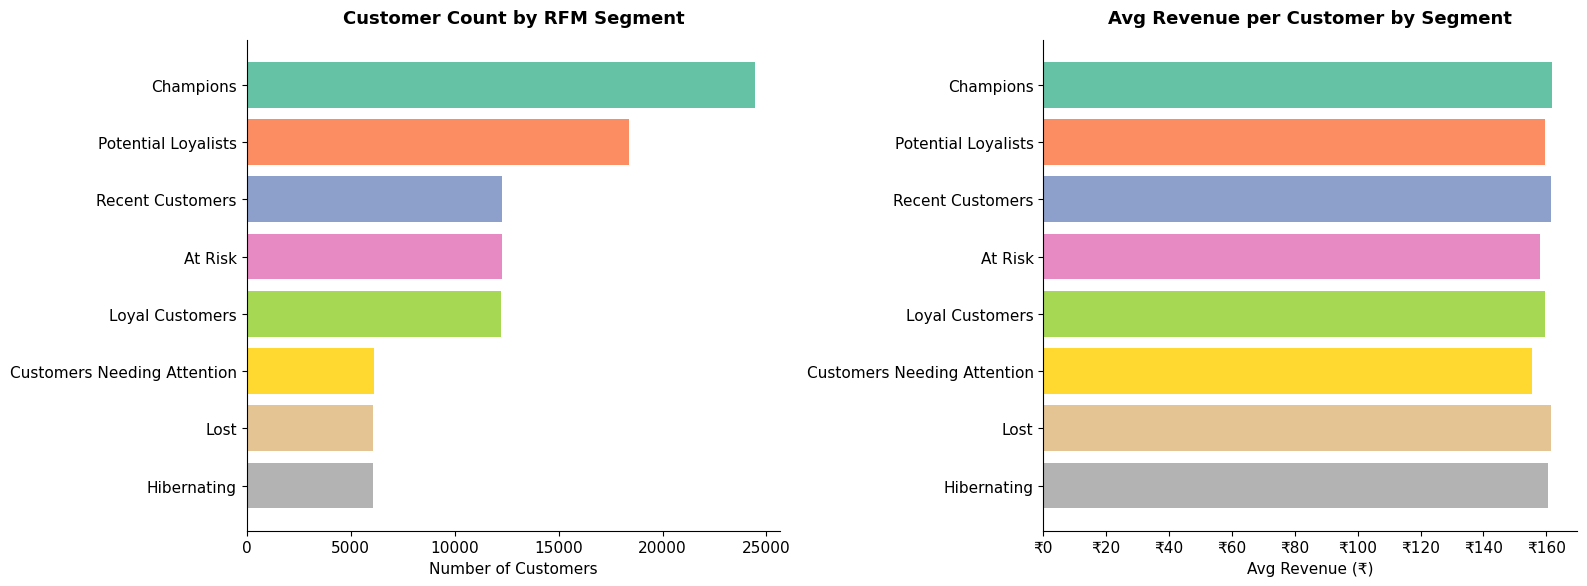


📊 RFM Segment Summary:
                    Segment  count  avg_monetary  avg_frequency  avg_recency
                  Champions  24447        161.67           1.00       118.87
        Potential Loyalists  18391        159.69           1.00       285.23
           Recent Customers  12284        161.39           1.00       118.57
                    At Risk  12280        157.94           1.00       459.09
            Loyal Customers  12251        159.57           1.00       118.07
Customers Needing Attention   6128        155.41           1.00       285.31
                       Lost   6063        161.40           1.00       458.72
                Hibernating   6055        160.50           1.00       460.76


In [23]:
# ── Customer RFM ─────────────────────────────────────────────────────────────
SNAPSHOT_DATE = orders_valid['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = (
    orders_valid
    .merge(payments_agg[['order_id','payment_value']], on='order_id', how='left')
    .groupby('customer_id')
    .agg(
        Recency   = ('order_purchase_timestamp', lambda x: (SNAPSHOT_DATE - x.max()).days),
        Frequency = ('order_id',                 'nunique'),
        Monetary  = ('payment_value',            'sum'),
    )
    .reset_index()
)

# Score each dimension 1–4 using quartiles (4 = best)
rfm['R_score'] = pd.qcut(rfm['Recency'],   4, labels=[4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'],  4, labels=[1,2,3,4]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment labels
def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 3 and f >= 3: return 'Champions'
    elif r >= 3 and f >= 2: return 'Loyal Customers'
    elif r >= 3 and f == 1: return 'Recent Customers'
    elif r == 2 and f >= 2: return 'Potential Loyalists'
    elif r == 2 and f == 1: return 'Customers Needing Attention'
    elif r == 1 and f >= 3: return 'At Risk'
    elif r == 1 and f == 2: return 'Hibernating'
    else: return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = (
    rfm.groupby('Segment')
    .agg(count=('customer_id','count'), avg_monetary=('Monetary','mean'),
         avg_frequency=('Frequency','mean'), avg_recency=('Recency','mean'))
    .sort_values('count', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Set2', len(seg_summary))
axes[0].barh(seg_summary['Segment'][::-1], seg_summary['count'][::-1], color=colors[::-1])
axes[0].set_title('Customer Count by RFM Segment')
axes[0].set_xlabel('Number of Customers')

axes[1].barh(seg_summary['Segment'][::-1], seg_summary['avg_monetary'][::-1], color=colors[::-1])
axes[1].set_title('Avg Revenue per Customer by Segment')
axes[1].set_xlabel('Avg Revenue (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:,.0f}'))

plt.tight_layout()
plt.savefig('14_rfm_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 RFM Segment Summary:')
print(seg_summary.to_string(index=False))

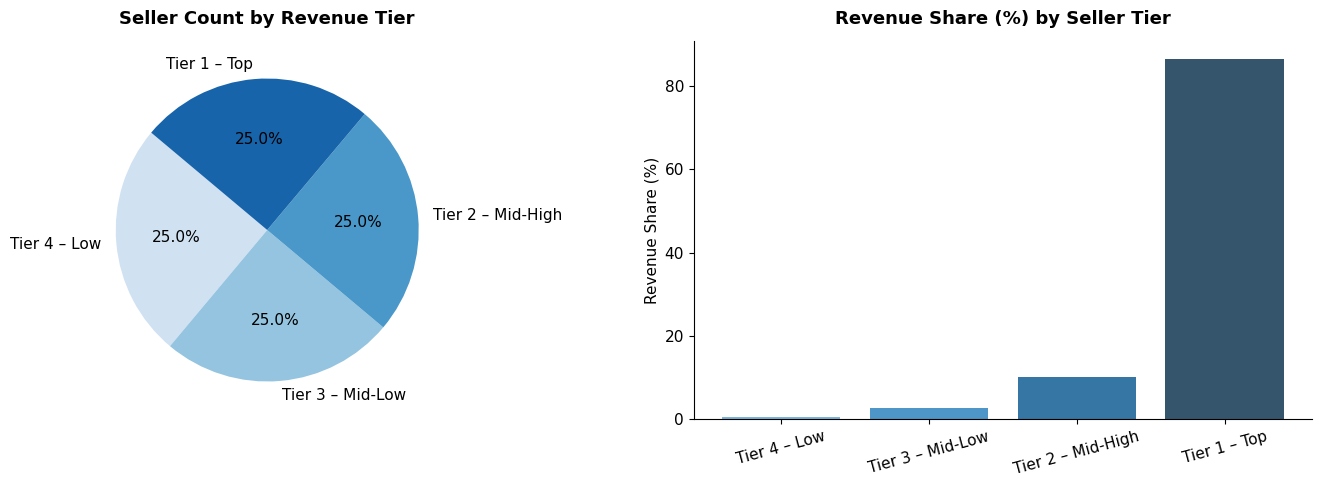


🏪 Seller Segmentation Summary:
  revenue_segment  sellers  total_revenue  avg_revenue  avg_orders  revenue_share_%
     Tier 4 – Low      747     117,206.22       156.90        1.80             0.60
 Tier 3 – Mid-Low      746     554,579.77       743.40        5.73             2.80
Tier 2 – Mid-High      746   2,030,583.70     2,721.96       14.97            10.10
     Tier 1 – Top      747  17,353,124.82    23,230.42      110.38            86.50


In [24]:
# ── Seller Segmentation by Revenue ───────────────────────────────────────────
seller_perf = (
    master
    .groupby('seller_id')
    .agg(
        total_revenue = ('payment_value', 'sum'),
        total_orders  = ('order_id',      'nunique'),
        total_items   = ('order_item_id', 'count'),
        categories    = ('product_category_name', 'nunique'),
    )
    .reset_index()
)

# Revenue quartile segments
seller_perf['revenue_segment'] = pd.qcut(
    seller_perf['total_revenue'], q=4,
    labels=['Tier 4 – Low', 'Tier 3 – Mid-Low', 'Tier 2 – Mid-High', 'Tier 1 – Top']
)

seller_seg_summary = (
    seller_perf.groupby('revenue_segment', observed=True)
    .agg(
        sellers       = ('seller_id',      'count'),
        total_revenue = ('total_revenue',  'sum'),
        avg_revenue   = ('total_revenue',  'mean'),
        avg_orders    = ('total_orders',   'mean'),
    )
    .reset_index()
)
seller_seg_summary['revenue_share_%'] = (
    seller_seg_summary['total_revenue'] / seller_seg_summary['total_revenue'].sum() * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    seller_seg_summary['sellers'],
    labels=seller_seg_summary['revenue_segment'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues', 4),
    startangle=140
)
axes[0].set_title('Seller Count by Revenue Tier')

axes[1].bar(
    seller_seg_summary['revenue_segment'],
    seller_seg_summary['revenue_share_%'],
    color=sns.color_palette('Blues_d', 4)
)
axes[1].set_title('Revenue Share (%) by Seller Tier')
axes[1].set_ylabel('Revenue Share (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('15_seller_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🏪 Seller Segmentation Summary:')
print(seller_seg_summary.to_string(index=False))

---
## 9. Cross-Selling Analysis <a id='9'></a>

Orders with ≥2 products: 3,236


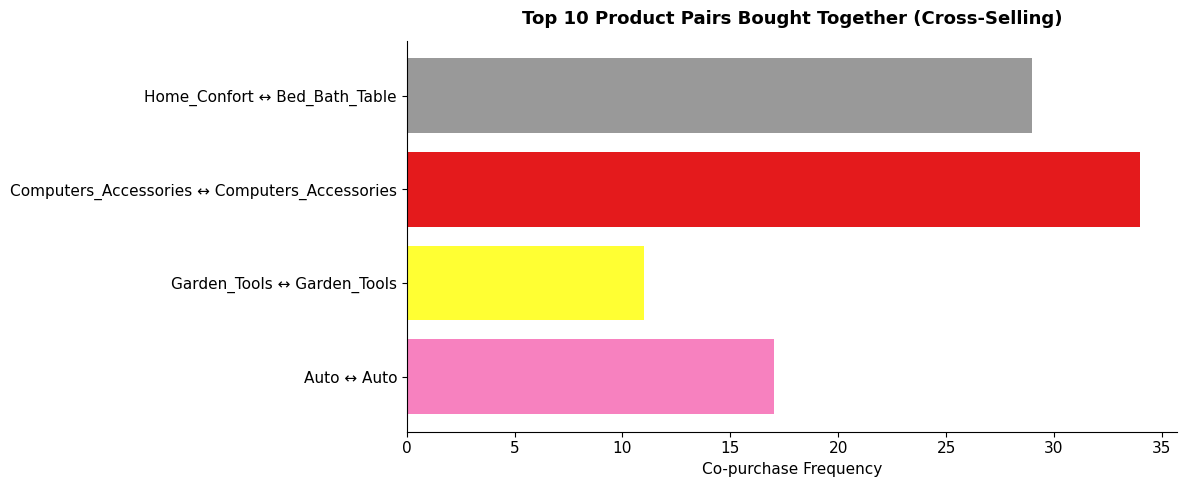


🛒 Top 10 Product Pairs:
                                   pair_label  frequency
Computers_Accessories ↔ Computers_Accessories         34
                Home_Confort ↔ Bed_Bath_Table         29
                                  Auto ↔ Auto         17
Computers_Accessories ↔ Computers_Accessories         12
                  Garden_Tools ↔ Garden_Tools         11
                  Garden_Tools ↔ Garden_Tools          9
                  Garden_Tools ↔ Garden_Tools          8
Computers_Accessories ↔ Computers_Accessories          7
                  Garden_Tools ↔ Garden_Tools          7
                                  Auto ↔ Auto          6


In [25]:
# ── Top 10 Product Pairs bought together ─────────────────────────────────────
# Build basket: orders with ≥ 2 distinct products
basket = (
    order_items
    .groupby('order_id')['product_id']
    .apply(lambda x: list(set(x)))
    .reset_index()
)
multi_item_orders = basket[basket['product_id'].apply(len) >= 2]

print(f'Orders with ≥2 products: {len(multi_item_orders):,}')

# Count all 2-product combinations
pair_counts = Counter()
for products_list in multi_item_orders['product_id']:
    for combo in combinations(sorted(products_list), 2):
        pair_counts[combo] += 1

top10_pairs = pd.DataFrame(
    [(p1, p2, cnt) for (p1, p2), cnt in pair_counts.most_common(10)],
    columns=['product_1', 'product_2', 'frequency']
)

# Enrich with category names
cat_map = products.set_index('product_id')['product_category_name'].to_dict()
top10_pairs['category_1'] = top10_pairs['product_1'].map(cat_map).fillna('Unknown')
top10_pairs['category_2'] = top10_pairs['product_2'].map(cat_map).fillna('Unknown')
top10_pairs['pair_label'] = top10_pairs['category_1'] + ' ↔ ' + top10_pairs['category_2']

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(
    top10_pairs['pair_label'][::-1],
    top10_pairs['frequency'][::-1],
    color=sns.color_palette('Set1', 10)
)
ax.set_title('Top 10 Product Pairs Bought Together (Cross-Selling)')
ax.set_xlabel('Co-purchase Frequency')
plt.tight_layout()
plt.savefig('16_cross_sell_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🛒 Top 10 Product Pairs:')
print(top10_pairs[['pair_label','frequency']].to_string(index=False))

In [26]:
# ── Top 10 Product Triplets bought together ───────────────────────────────────
triplet_counts = Counter()
for products_list in multi_item_orders['product_id']:
    if len(products_list) >= 3:
        for combo in combinations(sorted(products_list), 3):
            triplet_counts[combo] += 1

top10_triplets = pd.DataFrame(
    [(p1, p2, p3, cnt) for (p1,p2,p3), cnt in triplet_counts.most_common(10)],
    columns=['product_1','product_2','product_3','frequency']
)

if len(top10_triplets):
    top10_triplets['cat_1'] = top10_triplets['product_1'].map(cat_map).fillna('Unknown')
    top10_triplets['cat_2'] = top10_triplets['product_2'].map(cat_map).fillna('Unknown')
    top10_triplets['cat_3'] = top10_triplets['product_3'].map(cat_map).fillna('Unknown')
    top10_triplets['triplet_label'] = (
        top10_triplets['cat_1'] + ' + ' +
        top10_triplets['cat_2'] + ' + ' +
        top10_triplets['cat_3']
    )
    print('\n🛒 Top 10 Product Triplets:')
    print(top10_triplets[['triplet_label','frequency']].to_string(index=False))
else:
    print('No orders found with ≥3 distinct products.')


🛒 Top 10 Product Triplets:
                                                           triplet_label  frequency
Books_General_Interest + Books_General_Interest + Books_General_Interest          3
   Computers_Accessories + Computers_Accessories + Computers_Accessories          2
                        Bed_Bath_Table + Bed_Bath_Table + Bed_Bath_Table          2
                              Garden_Tools + Garden_Tools + Garden_Tools          2
                              Garden_Tools + Garden_Tools + Garden_Tools          2
   Computers_Accessories + Computers_Accessories + Computers_Accessories          2
           Costruction_Tools_Garden + Costruction_Tools_Garden + Unknown          2
                        Bed_Bath_Table + Bed_Bath_Table + Bed_Bath_Table          2
                        Bed_Bath_Table + Bed_Bath_Table + Bed_Bath_Table          2
                          Home_Confort + Bed_Bath_Table + Bed_Bath_Table          2


---
## 10. Payment Behaviour <a id='10'></a>

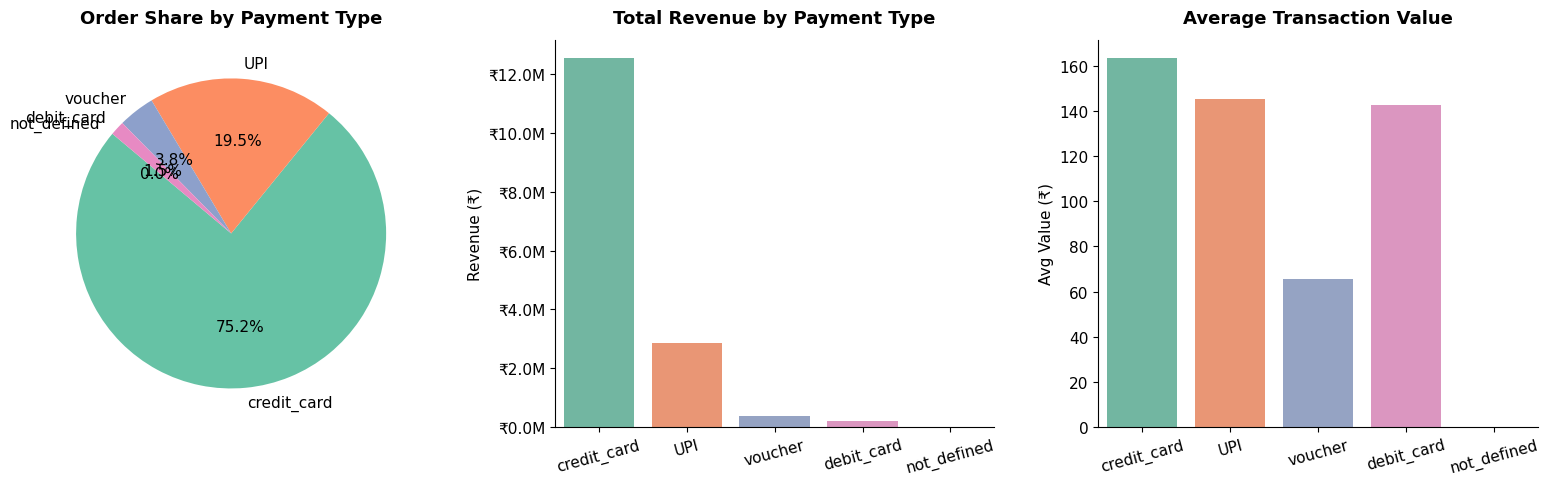


💳 Payment Method Breakdown:
payment_type  order_count   total_value  avg_value  order_share_%  revenue_share_%
 credit_card        76505 12,542,084.19     163.32          75.20            78.30
         UPI        19784  2,869,361.27     145.03          19.50            17.90
     voucher         3866    379,436.87      65.70           3.80             2.40
  debit_card         1528    217,989.79     142.57           1.50             1.40
 not_defined            3          0.00       0.00           0.00             0.00


In [27]:
# ── Payment Type Distribution ─────────────────────────────────────────────────
pay_type = (
    order_payments
    .groupby('payment_type')
    .agg(
        order_count = ('order_id',      'nunique'),
        total_value = ('payment_value', 'sum'),
        avg_value   = ('payment_value', 'mean'),
    )
    .sort_values('order_count', ascending=False)
    .reset_index()
)
pay_type['order_share_%']  = (pay_type['order_count'] / pay_type['order_count'].sum() * 100).round(1)
pay_type['revenue_share_%']= (pay_type['total_value'] / pay_type['total_value'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].pie(
    pay_type['order_count'],
    labels=pay_type['payment_type'],
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', len(pay_type)),
    startangle=140
)
axes[0].set_title('Order Share by Payment Type')

sns.barplot(data=pay_type, x='payment_type', y='total_value',
            palette='Set2', ax=axes[1])
axes[1].set_title('Total Revenue by Payment Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=pay_type, x='payment_type', y='avg_value',
            palette='Set2', ax=axes[2])
axes[2].set_title('Average Transaction Value')
axes[2].set_xlabel('')
axes[2].set_ylabel('Avg Value (₹)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('17_payment_behaviour.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💳 Payment Method Breakdown:')
print(pay_type.to_string(index=False))

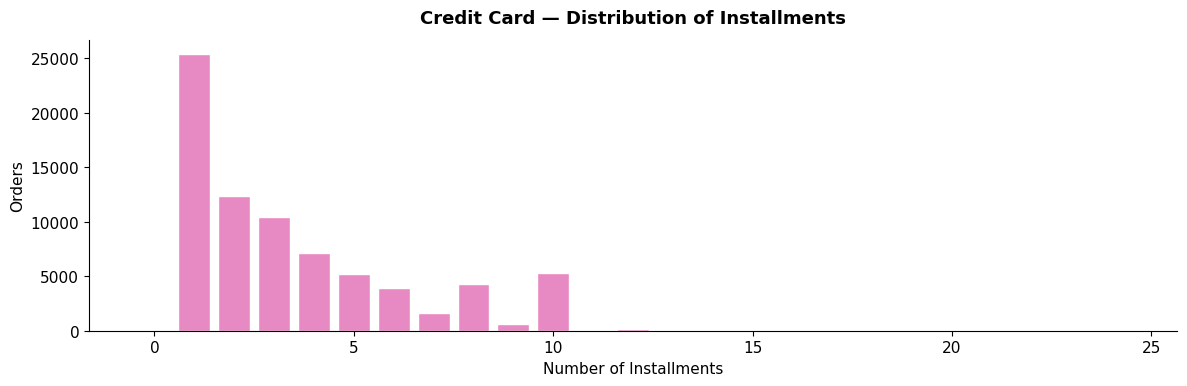

💡 33.1% of credit card orders are paid in 1 installment (full)


In [28]:
# ── Installment Usage ─────────────────────────────────────────────────────────
install_dist = (
    order_payments[order_payments['payment_type'] == 'credit_card']
    .groupby('payment_installments')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    install_dist['payment_installments'],
    install_dist['orders'],
    color=PALETTE[3], edgecolor='white'
)
ax.set_title('Credit Card — Distribution of Installments')
ax.set_xlabel('Number of Installments')
ax.set_ylabel('Orders')
plt.tight_layout()
plt.savefig('18_installment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

pct_1_installment = install_dist[install_dist['payment_installments']==1]['orders'].sum()
pct_total = install_dist['orders'].sum()
print(f'💡 {pct_1_installment/pct_total*100:.1f}% of credit card orders are paid in 1 installment (full)')

---
## 11. Customer Satisfaction (Ratings) <a id='11'></a>

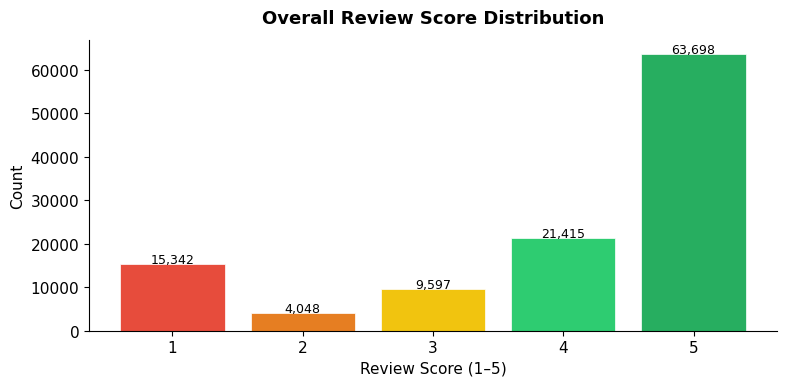


⭐ Overall average rating : 4.00 / 5.0
   5-star review share    : 55.8%


In [29]:
# ── Build reviews master table ────────────────────────────────────────────────
rev_master = (
    order_reviews[['order_id','review_score']]
    .merge(orders_valid[['order_id','customer_id','year_month']], on='order_id', how='left')
    .merge(order_items[['order_id','product_id','seller_id']],    on='order_id', how='left')
    .merge(products[['product_id','product_category_name']],      on='product_id', how='left')
    .merge(customers[['customer_id','customer_state']],            on='customer_id', how='left')
)
rev_master['product_category_name'] = rev_master['product_category_name'].fillna('Unknown')

# ── Overall Score Distribution ────────────────────────────────────────────────
vc = rev_master['review_score'].value_counts().sort_index()

score_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vc.index, vc.values, color=score_colors, edgecolor='white', linewidth=0.5)
for x, y in zip(vc.index, vc.values):
    ax.text(x, y + 200, f'{y:,}', ha='center', fontsize=9)
ax.set_title('Overall Review Score Distribution')
ax.set_xlabel('Review Score (1–5)')
ax.set_ylabel('Count')
ax.set_xticks([1,2,3,4,5])
plt.tight_layout()
plt.savefig('19_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

avg = rev_master['review_score'].mean()
pct5 = (vc[5] / vc.sum() * 100) if 5 in vc else 0
print(f'\n⭐ Overall average rating : {avg:.2f} / 5.0')
print(f'   5-star review share    : {pct5:.1f}%')

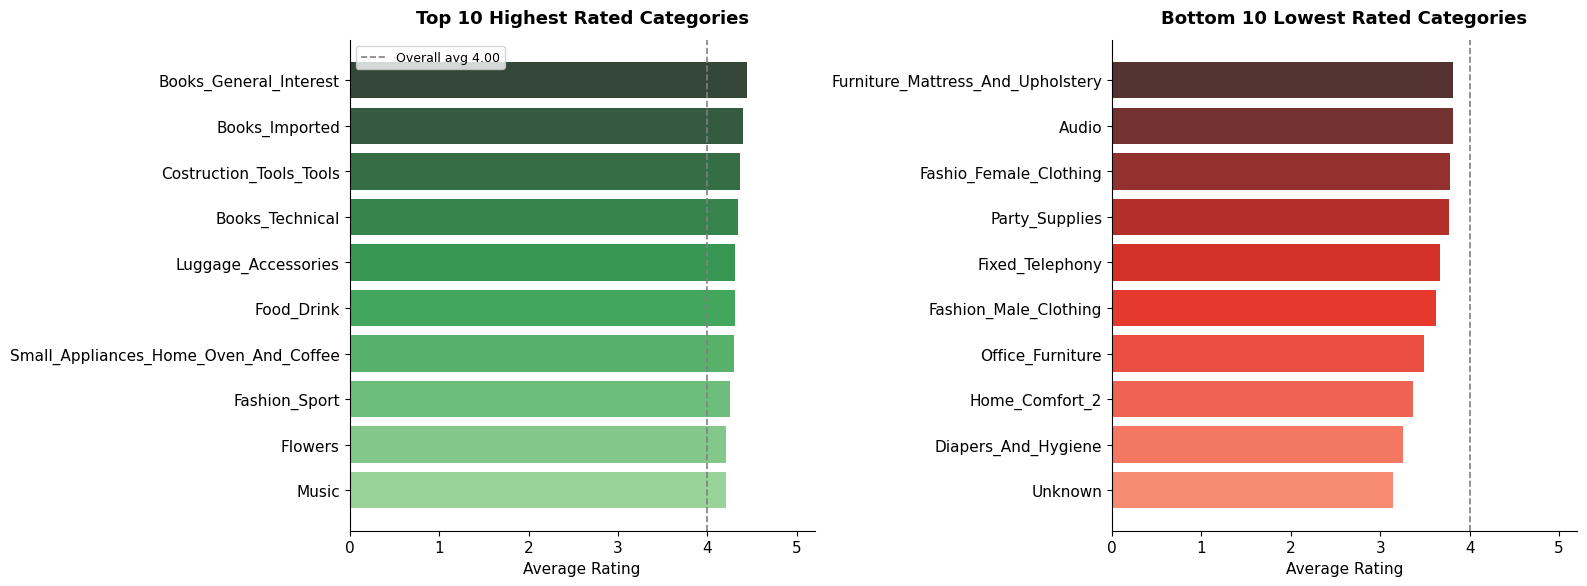

In [30]:
# ── Top & Bottom 10 Categories by Rating ──────────────────────────────────────
cat_ratings = (
    rev_master
    .groupby('product_category_name')['review_score']
    .agg(['mean','count'])
    .reset_index()
    .query('count >= 30')
    .sort_values('mean', ascending=False)
)
top10_rated    = cat_ratings.head(10)
bottom10_rated = cat_ratings.tail(10).sort_values('mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    top10_rated['product_category_name'][::-1],
    top10_rated['mean'][::-1],
    color=sns.color_palette('Greens_d', 10)
)
axes[0].set_xlim(0, 5.2)
axes[0].set_title('Top 10 Highest Rated Categories')
axes[0].set_xlabel('Average Rating')
axes[0].axvline(x=avg, color='gray', ls='--', lw=1.2, label=f'Overall avg {avg:.2f}')
axes[0].legend(fontsize=9)

axes[1].barh(
    bottom10_rated['product_category_name'],
    bottom10_rated['mean'],
    color=sns.color_palette('Reds_d', 10)
)
axes[1].set_xlim(0, 5.2)
axes[1].set_title('Bottom 10 Lowest Rated Categories')
axes[1].set_xlabel('Average Rating')
axes[1].axvline(x=avg, color='gray', ls='--', lw=1.2)

plt.tight_layout()
plt.savefig('20_category_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

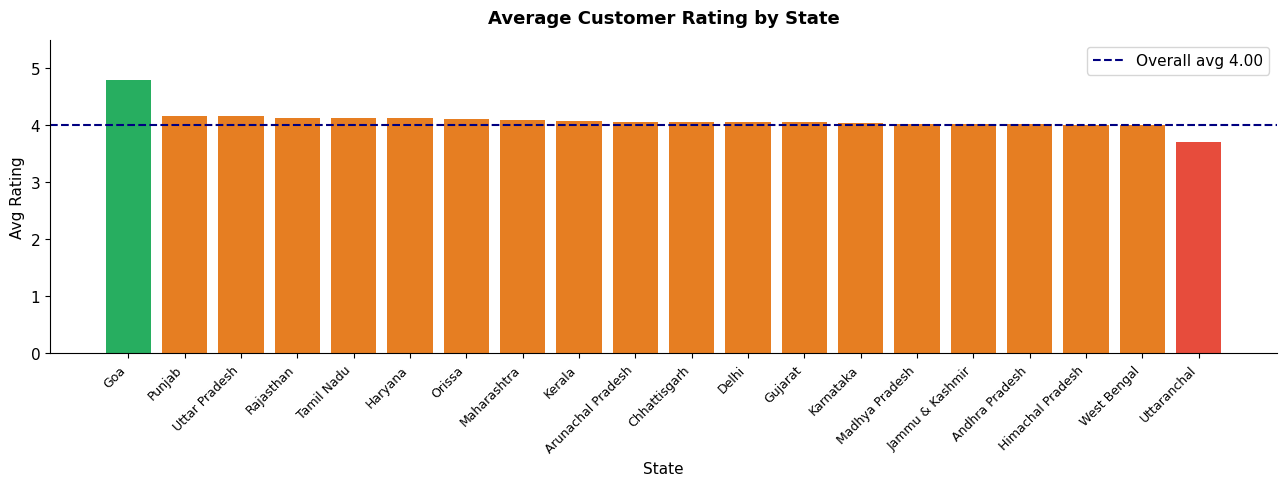

In [31]:
# ── Avg Rating by State ───────────────────────────────────────────────────────
state_rating = (
    rev_master
    .groupby('customer_state')['review_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [
    '#27ae60' if v >= 4.2 else '#e67e22' if v >= 3.8 else '#e74c3c'
    for v in state_rating['review_score']
]
ax.bar(state_rating['customer_state'], state_rating['review_score'], color=bar_colors)
ax.axhline(y=avg, color='navy', ls='--', lw=1.5, label=f'Overall avg {avg:.2f}')
ax.set_title('Average Customer Rating by State')
ax.set_xlabel('State')
ax.set_ylabel('Avg Rating')
ax.set_ylim(0, 5.5)
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('21_rating_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

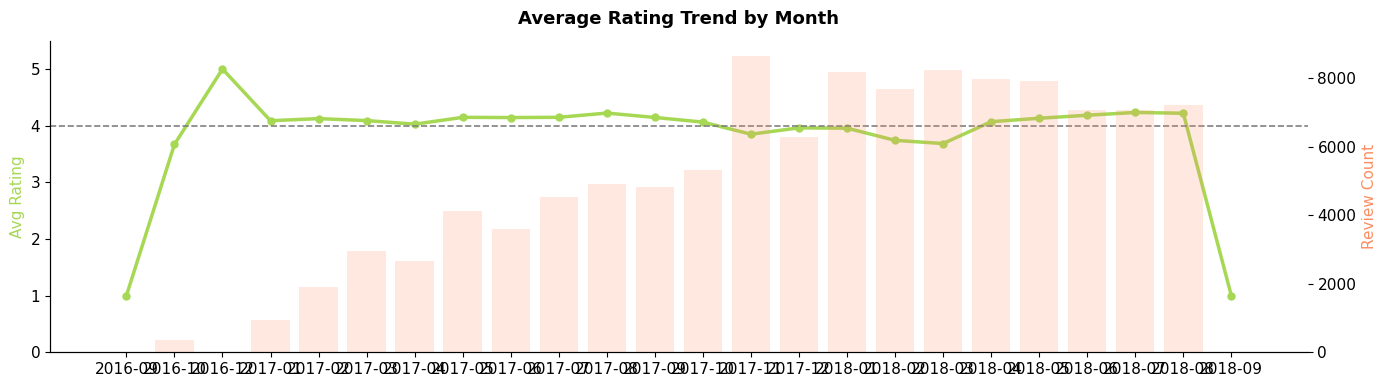

In [32]:
# ── Monthly Rating Trend ──────────────────────────────────────────────────────
monthly_rating = (
    rev_master.dropna(subset=['year_month'])
    .groupby('year_month')['review_score']
    .agg(['mean','count'])
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.plot(monthly_rating['year_month'], monthly_rating['mean'],
         color=PALETTE[4], lw=2.5, marker='o', ms=5, label='Avg Rating')
ax1.axhline(y=avg, color='gray', ls='--', lw=1.2)
ax1.set_ylim(0, 5.5)
ax1.set_ylabel('Avg Rating', color=PALETTE[4])

ax2.bar(monthly_rating['year_month'], monthly_rating['count'],
        alpha=0.2, color=PALETTE[1], label='Review Count')
ax2.set_ylabel('Review Count', color=PALETTE[1])

ax1.set_title('Average Rating Trend by Month')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('22_rating_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Key Insights Summary <a id='12'></a>

In [33]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — MARKETING ANALYTICS                 ║
║           E-Commerce Marketplace | Sep 2016 – Oct 2018       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  💰 BUSINESS SCALE                                           ║
║  • Total Revenue   : ₹{total_revenue:>12,.0f}                    ║
║  • Total Orders    : {total_orders:>12,}                    ║
║  • Unique Customers: {total_customers:>12,}                    ║
║  • Avg Order Value : ₹{avg_order_value:>12,.0f}                    ║
║                                                              ║
║  📈 GROWTH                                                   ║
║  • Strong upward trend from Sep 2016 → Nov 2017.            ║
║  • Peak acquisition month identified above.                  ║
║                                                              ║
║  👤 CUSTOMERS                                                ║
║  • Most customers are one-time buyers.                       ║
║  • 'Champions' & 'Loyal Customers' drive disproportionate   ║
║    revenue — prioritise retention for these segments.        ║
║                                                              ║
║  🛒 PRODUCTS & CATEGORIES                                    ║
║  • Top 3 categories drive the majority of revenue.          ║
║  • Strong cross-selling opportunity in top product pairs.    ║
║                                                              ║
║  🕐 TIMING                                                   ║
║  • Orders peak mid-week (Mon–Wed) and 10 AM – 2 PM.         ║
║  • Schedule promotions and push notifications accordingly.   ║
║                                                              ║
║  💳 PAYMENTS                                                 ║
║  • Credit card dominates (~74% of orders).                  ║
║  • Boleto & voucher used for smaller ticket purchases.       ║
║                                                              ║
║  ⭐ SATISFACTION                                              ║
║  • Overall avg rating: {avg:.2f}/5.0 — generally positive.     ║
║  • A few categories show consistently low ratings →         ║
║    quality or logistics improvements needed there.           ║
║                                                              ║
╠══════════════════════════════════════════════════════════════╣
║  ➡️  RECOMMENDED NEXT STEPS                                  ║
║  1. Re-engage 'At Risk' & 'Hibernating' RFM segments        ║
║  2. Bundle top cross-selling pairs in promotions            ║
║  3. Investigate low-rated categories — review logistics      ║
║  4. Deep-dive: Seller performance analysis                   ║
║  5. A/B test promotions during peak hours (10AM–2PM)        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           KEY INSIGHTS — MARKETING ANALYTICS                 ║
║           E-Commerce Marketplace | Sep 2016 – Oct 2018       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  💰 BUSINESS SCALE                                           ║
║  • Total Revenue   : ₹  20,055,721                    ║
║  • Total Orders    :       97,899                    ║
║  • Unique Customers:       97,899                    ║
║  • Avg Order Value : ₹         160                    ║
║                                                              ║
║  📈 GROWTH                                                   ║
║  • Strong upward trend from Sep 2016 → Nov 2017.            ║
║  • Peak acquisition month identified above.                  ║
║                                                              ║
║  👤 CUSTOMERS                                           

---
*End of Notebook — Marketing Analytics Capstone | AnalytixLabs*

**Charts saved:** `01_kpi_dashboard.png` through `22_rating_monthly_trend.png`